# Labour Force Data
Labour force status for adults with disabilities by disability type: https://open.canada.ca/data/en/dataset/92aeb8dc-c7ca-4f44-81df-fdaf289d23fd 

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

In [2]:
# Load data

labour_force = pd.read_csv("../data/raw/labour_force/13100348.csv")
labour_force.head()

,REF_DATE,GEO,DGUID,Sex,Age group,Disability type,Global Severity,Labour force status,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,2012,Canada,2016A000011124,Both sexes,"Total, 15 to 64 years",All disability types,"Total population, severity of disability",Total labour force,Number,223,units,0,v91886462,1.1.1.1.1.1,2338240.0,NaN,NaN,NaN,0
1,2012,Canada,2016A000011124,Both sexes,"Total, 15 to 64 years",All disability types,"Total population, severity of disability",Employed,Number,223,units,0,v91886463,1.1.1.1.1.2,1026910.0,NaN,NaN,NaN,0
2,2012,Canada,2016A000011124,Both sexes,"Total, 15 to 64 years",All disability types,"Total population, severity of disability",Unemployed,Number,223,units,0,v91886464,1.1.1.1.1.3,137450.0,NaN,NaN,NaN,0
3,2012,Canada,2016A000011124,Both sexes,"Total, 15 to 64 years",All disability types,"Total population, severity of disability",Not in labour force,Number,223,units,0,v91886465,1.1.1.1.1.4,1007660.0,NaN,NaN,NaN,0
4,2012,Canada,2016A000011124,Both sexes,"Total, 15 to 64 years",All disability types,"Total population, severity of disability",Participation rate,Percent,239,units,0,v91886466,1.1.1.1.1.5,53.6,NaN,NaN,NaN,1


In [3]:
labour_force.tail()

,REF_DATE,GEO,DGUID,Sex,Age group,Disability type,Global Severity,Labour force status,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
151195,2012,Nunavut,2016A000262,Females,55 to 64 years,Unknown disability type,Very Severe,Age standardized participation rate,Percent,239,units,0,v92037657,14.3.6.12.5.6,NaN,F,NaN,NaN,1
151196,2012,Nunavut,2016A000262,Females,55 to 64 years,Unknown disability type,Very Severe,Employment Rate,Percent,239,units,0,v92037658,14.3.6.12.5.7,NaN,F,NaN,NaN,1
151197,2012,Nunavut,2016A000262,Females,55 to 64 years,Unknown disability type,Very Severe,Age standardized employment rate,Percent,239,units,0,v92037659,14.3.6.12.5.8,NaN,F,NaN,NaN,1
151198,2012,Nunavut,2016A000262,Females,55 to 64 years,Unknown disability type,Very Severe,Unemployment rate,Percent,239,units,0,v92037660,14.3.6.12.5.9,NaN,F,NaN,NaN,1
151199,2012,Nunavut,2016A000262,Females,55 to 64 years,Unknown disability type,Very Severe,Age standardized unemployment rate,Percent,239,units,0,v92037661,14.3.6.12.5.10,NaN,F,NaN,NaN,1


## 1. EDA

In [4]:
labour_force.shape

(151200, 19)

In [5]:
labour_force.info()

<class 'pandas.DataFrame'>
RangeIndex: 151200 entries, 0 to 151199
Data columns (total 19 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   REF_DATE             151200 non-null  int64  
 1   GEO                  151200 non-null  str    
 2   DGUID                151200 non-null  str    
 3   Sex                  151200 non-null  str    
 4   Age group            151200 non-null  str    
 5   Disability type      151200 non-null  str    
 6   Global Severity      151200 non-null  str    
 7   Labour force status  151200 non-null  str    
 8   UOM                  151200 non-null  str    
 9   UOM_ID               151200 non-null  int64  
 10  SCALAR_FACTOR        151200 non-null  str    
 11  SCALAR_ID            151200 non-null  int64  
 12  VECTOR               151200 non-null  str    
 13  COORDINATE           151200 non-null  str    
 14  VALUE                34597 non-null   float64
 15  STATUS               136535 

In [6]:
labour_force['Sex'].value_counts()

Sex
Both sexes    50400
Males         50400
Females       50400
Name: count, dtype: int64

In [7]:
labour_force['Age group'].value_counts()

Age group
Total, 15 to 64 years    25200
15 to 24 years           25200
25 to 34 years           25200
35 to 44 years           25200
45 to 54 years           25200
55 to 64 years           25200
Name: count, dtype: int64

In [8]:
labour_force['Global Severity'].value_counts()

Global Severity
Total population, severity of disability    30240
Mild                                        30240
Moderate                                    30240
Severe                                      30240
Very Severe                                 30240
Name: count, dtype: int64

In [9]:
labour_force['Disability type'].value_counts()

Disability type
All disability types           12600
Seeing                         12600
Hearing                        12600
Mobility                       12600
Flexibility                    12600
Dexterity                      12600
Pain                           12600
Learning                       12600
Memory                         12600
Developmental                  12600
Mental and/or psychological    12600
Unknown disability type        12600
Name: count, dtype: int64

In [10]:
labour_force['Labour force status'].value_counts()

Labour force status
Total labour force                     15120
Employed                               15120
Unemployed                             15120
Not in labour force                    15120
Participation rate                     15120
Age standardized participation rate    15120
Employment Rate                        15120
Age standardized employment rate       15120
Unemployment rate                      15120
Age standardized unemployment rate     15120
Name: count, dtype: int64

In [25]:
labour_force['UOM'].value_counts()

UOM
Percent    90720
Number     60480
Name: count, dtype: int64

In [12]:
# Symbol legend: E use with caution, F too unreliable to be published
labour_force['STATUS'].value_counts()

STATUS
F    116603
E     19932
Name: count, dtype: int64

In [24]:
# 2. Condition 1: STATUS is 'F' but VALUE is NOT missing (not NaN)
f_but_has_value = labour_force[(labour_force['STATUS'] == 'F') & (labour_force['VALUE'].notnull())]

# 3. Condition 2: VALUE is missing (NaN) but STATUS is NOT 'F'
nan_but_not_f = labour_force[labour_force['VALUE'].isnull() & (labour_force['STATUS'] != 'F')]

# 4. Print individual condition results
print(f"Rows where STATUS == 'F' but VALUE is present: {len(f_but_has_value)}")
print(f"Rows where VALUE is NaN but STATUS != 'F':     {len(nan_but_not_f)}")

# 5. Print aggregate counts for full verification
print("\n--- Aggregate Count Check ---")
print(f"Total rows in dataset:             {len(labour_force):,}")
print(f"Total rows with STATUS == 'F':      {(labour_force['STATUS'] == 'F').sum():,}")
print(f"Total rows with VALUE as NaN:      {labour_force['VALUE'].isnull().sum():,}")

Rows where STATUS == 'F' but VALUE is present: 0
Rows where VALUE is NaN but STATUS != 'F':     0

--- Aggregate Count Check ---
Total rows in dataset:             151,200
Total rows with STATUS == 'F':      116,603
Total rows with VALUE as NaN:      116,603


In [21]:
# Look at the unmasked dataset to check suppression rates (nan for 'VALUE' col or 'F' for 'STATUS' col) across categories
features_to_check = ['GEO', 'Sex', 'Age group', 'Disability type', 'Global Severity']

for col in features_to_check:
    print(f"--- Suppression Rate by {col} ---")
    # Calculate percentage of rows with status 'F' or null values per category
    sparsity = labour_force.groupby(col)['VALUE'].apply(lambda x: (x.isnull()).mean() * 100)
    print(sparsity.sort_values(ascending=False))
    print("\n")

--- Suppression Rate by GEO ---
GEO
Nunavut                      94.490741
Northwest Territories        92.879630
Yukon                        92.620370
Prince Edward Island         83.694444
Newfoundland and Labrador    83.444444
New Brunswick                77.537037
Quebec                       77.250000
Ontario                      74.407407
Nova Scotia                  74.175926
Saskatchewan                 73.685185
British Columbia             73.361111
Alberta                      71.842593
Manitoba                     70.861111
Canada                       39.407407
Name: VALUE, dtype: float64


--- Suppression Rate by Sex ---
Sex
Males         81.626984
Females       79.960317
Both sexes    69.767857
Name: VALUE, dtype: float64


--- Suppression Rate by Age group ---
Age group
25 to 34 years           87.523810
15 to 24 years           82.607143
45 to 54 years           80.849206
35 to 44 years           80.067460
55 to 64 years           79.551587
Total, 15 to 64 years    52

## 2. Data Cleaning

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("../data/raw/labour_force/13100348.csv")

# Filter for Employment Rate and aggregate disability types to maximize sample size
macro_df = df[
    (df['Labour force status'] == 'Employment Rate') & 
    (df['VALUE'].notnull()) & 
    (df['GEO'] != 'Canada') &                                              # Exclude national average
    (df['Sex'] != 'Both sexes') &                                          # Exclude gender average
    (df['Age group'] != 'Total, 15 to 64 years') &                         # Exclude age average
    (df['Disability type'] == 'All disability types') &                    # Lock to all disabilities
    (df['Global Severity'] != 'Total population, severity of disability')  # Exclude severity average
].copy()

print(f"Macro subset rows available: {len(macro_df)}")

Macro subset rows available: 219


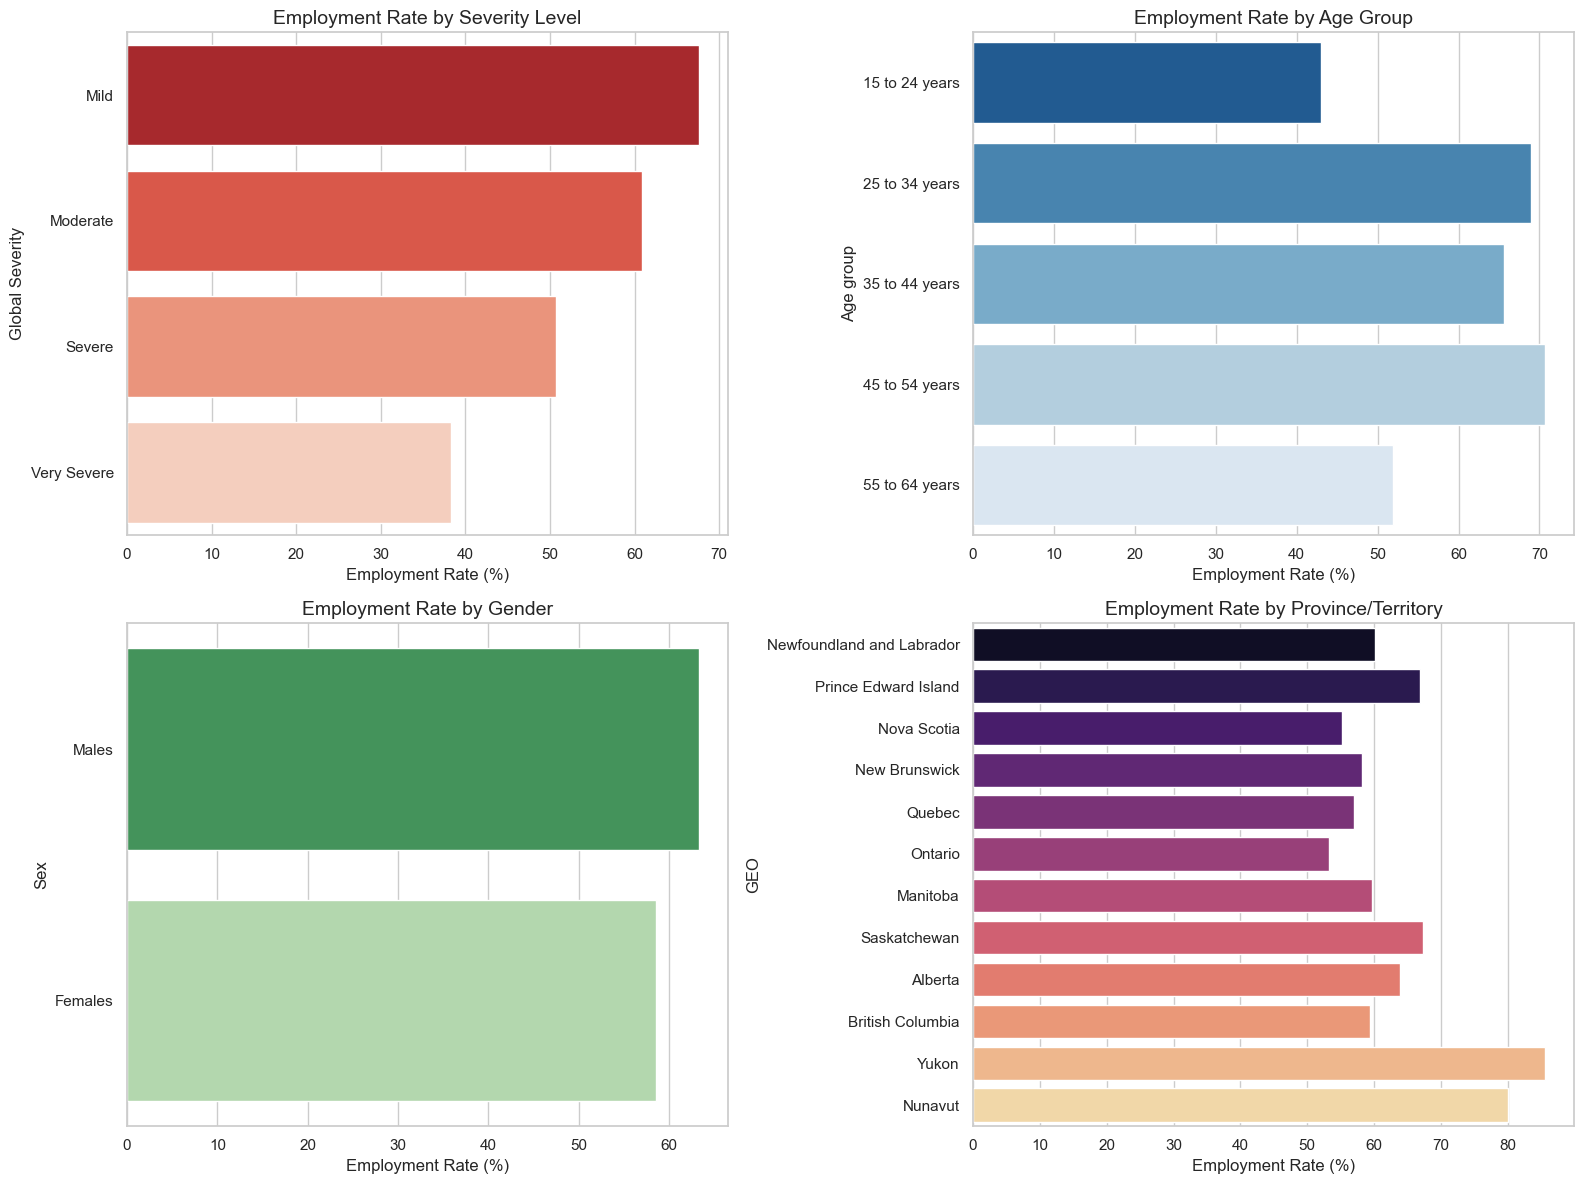

In [29]:
# Set the visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Severity Driver
sns.barplot(data=macro_df, x='VALUE', y='Global Severity', hue='Global Severity', ax=axes[0,0], errorbar=None, palette="Reds_r", legend=False)
axes[0,0].set_title('Employment Rate by Severity Level', fontsize=14)
axes[0,0].set_xlabel('Employment Rate (%)')

# 2. Age Driver
sns.barplot(data=macro_df, x='VALUE', y='Age group', hue='Age group', ax=axes[0,1], errorbar=None, palette="Blues_r", legend=False)
axes[0,1].set_title('Employment Rate by Age Group', fontsize=14)
axes[0,1].set_xlabel('Employment Rate (%)')

# 3. Gender Driver
sns.barplot(data=macro_df, x='VALUE', y='Sex', hue='Sex', ax=axes[1,0], errorbar=None, palette="Greens_r", legend=False)
axes[1,0].set_title('Employment Rate by Gender', fontsize=14)
axes[1,0].set_xlabel('Employment Rate (%)')

# 4. Location Driver
sns.barplot(data=macro_df, x='VALUE', y='GEO', hue='GEO', ax=axes[1,1], errorbar=None, palette="magma", legend=False)
axes[1,1].set_title('Employment Rate by Province/Territory', fontsize=14)
axes[1,1].set_xlabel('Employment Rate (%)')

plt.tight_layout()
plt.show()

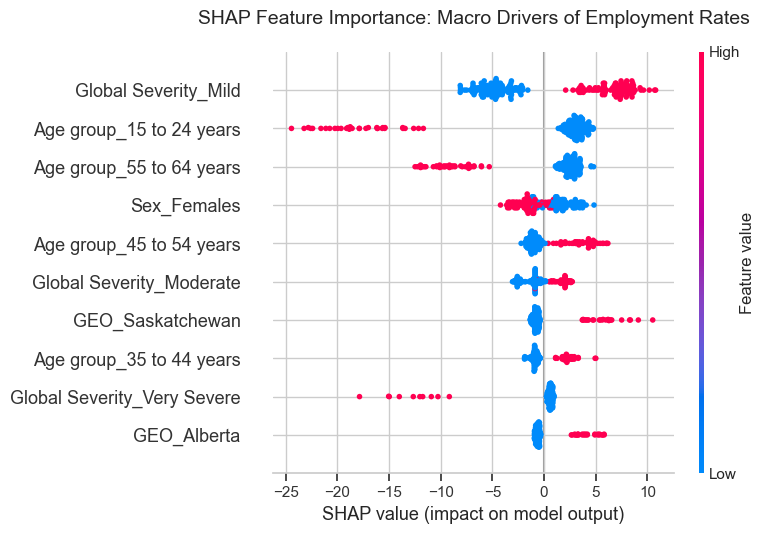

In [28]:
import xgboost as xgb
import shap

# Isolate the four macro features
features = ['GEO', 'Sex', 'Age group', 'Global Severity']

# One-hot encode without dropping the first category for better interpretability
X_macro = pd.get_dummies(macro_df[features], drop_first=False)
y_macro = macro_df['VALUE']

# Train the macro model
# Using simpler hyperparameters since we are focused on inference, not extreme prediction accuracy
macro_model = xgb.XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
macro_model.fit(X_macro, y_macro)

# Compute SHAP values
explainer = shap.TreeExplainer(macro_model)
shap_values = explainer(X_macro)

# Generate the ranking plot (Top 10 most impactful specific factors)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_macro, max_display=10, show=False)
plt.title("SHAP Feature Importance: Macro Drivers of Employment Rates", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

## 1. Interpretation of a SHAP Plot

* **Vertical Ranking (Feature Importance):** Features are ordered from top to bottom based on their overall impact on the model's predictions. The higher a feature is on the graph, the more it influences employment rates.
* **Horizontal Axis (SHAP Value / Direction of Impact):**
* **Points to the right of 0.0:** Increase the predicted employment rate.
* **Points to the left of 0.0:** Decrease the predicted employment rate.


* **Color Gradient (Feature Value):**
* Because these features are **One-Hot Encoded** (binary `0` or `1`):
* **Red (High = 1):** The data point belongs to that category (e.g., `Sex_Females = 1`).
* **Blue (Low = 0):** The data point does *not* belong to that category.

---

## 2. Key Takeaways from the Data

### **Disability Severity & Youth Are the Strongest Bottlenecks**

* **`Global Severity_Mild` (Top Feature):**
* **Red dots (Having a mild disability):** Cluster strongly to the right (**+3% to +10%** boost to employment rates).
* **Blue dots (Not mild):** Pull employment rates down by **-2% to -8%**.


* **`Age group_15 to 24 years`:**
* **Red dots:** Pull employment rates down drastically, extending as far left as **-10% to -24%**. Youth with disabilities face the steepest employment deficit of any single group.


* **`Age group_55 to 64 years`:**
* **Red dots:** Show a solid negative drag of **-4% to -12%**, capturing early retirement or labor force exit among older adults with disabilities.


* **`Global Severity_Very Severe`:**
* **Red dots:** Extend far to the left (**-8% to -18%** impact), confirming that severe impairments severely reduce labor market participation.



### **Core Working Age & Specific Regions Boost Employment**

* **`Age group_45 to 54 years` & `Age group_35 to 44 years`:**
* **Red dots:** Cluster on the right side (**+2% to +6%** impact), demonstrating that prime working-age adults experience higher employment rates.


* **`GEO_Saskatchewan` & `GEO_Alberta`:**
* **Red dots:** Show a positive impact (**+2% to +10%**), indicating that living in these provinces raises expected employment rates relative to other regions.



### **Gender Has a Small, Consistent Drag**

* **`Sex_Females`:**
* **Red dots:** Slightly shifted to the left (**-1% to -4%** impact), showing a modest systemic reduction in employment rates for women compared to men across equivalent disability and age brackets.



---

## Summary 

The plot clearly confirms that **disability severity and age stage** (specifically youth and near-retirement) are the primary drivers of employment variance in Canada. Geographic location and gender act as secondary modifiers.